# Pattern Recognition 2 - Feature Space

**Objectives**

* Compute distances between objects in feature space
* Use PCA to perform reduce the dimensionality of the problem
* Implement face recognition using [Eigenfaces](http://en.wikipedia.org/wiki/Eigenface)

## Feature space distance

The `ocr_features.npy` file contains extracted features for each letter from the document used in the previous lab, and the `ocr_class.npy` file contains the character corresponding to these features.

The 18 features, extracted with the `regionprops` methods from `scikit-image` are, in order: 

> area, convex area, eccentricity, equivalent diameter, extent, filled area, intertia tensor eigenvalue 1, inertia tensor eigenvalue 2, major axis length, minor axis length, Hu moment 1, Hu moment 2, Hu moment 3, Hu moment 4, Hu moment 5, Hu moment 6, perimeter, solidity

* Create a method which computes the Euclidian distance, in feature space, between two objects.
* Check if the "nearest" object is of the same class.
* What can you do to improve this "distance-based" classification? 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

ocr_features = np.load('/Users/alice/Desktop/INFO-H501 - Pattern/PR2/ocr_features.npy')
ocr_class = np.load('/Users/alice/Desktop/INFO-H501 - Pattern/PR2/ocr_class.npy')
faces = np.load('/Users/alice/Desktop/INFO-H501 - Pattern/PR2/faces.npy')

print('ocr_features shape:', ocr_features.shape)
print('ocr_class unique:', np.unique(ocr_class))
print('faces shape:', faces.shape, faces.dtype, faces.min(), faces.max())

ocr_features shape: (2392, 18)
ocr_class unique: ['0' '1' '4' '5' 'A' 'B' 'C' 'D' 'F' 'G' 'I' 'L' 'M' 'N' 'O' 'R' 'S' 'T'
 'W' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']
faces shape: (2963, 200, 170) uint8 0 255


/var/folders/r5/31bb5f9j375c1rgyg3v1v_lc0000gn/T/ipykernel_62992/3992355407.py:7: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  faces = np.load('/Users/alice/Desktop/INFO-H501 - Pattern/PR2/faces.npy')


The euclidean distance gives the straight line distance btw two points in that space. The 1-NN classifier find the closest stored character given a query character and predict it has the same class.

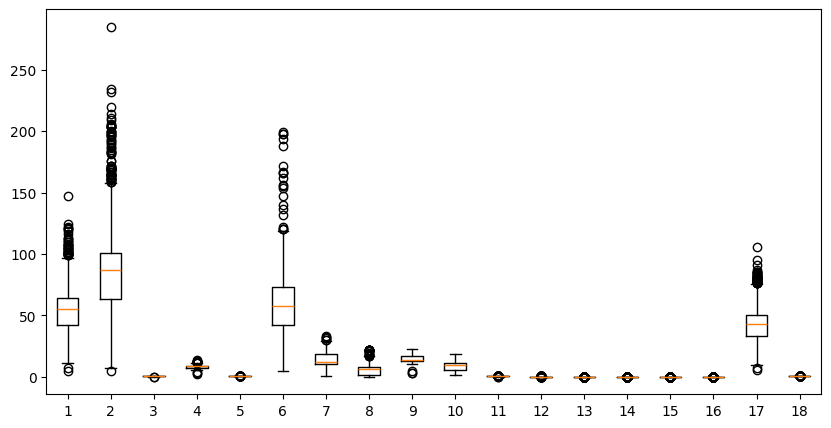

In [23]:
plt.figure(figsize=(10, 5))
plt.boxplot(ocr_features)
plt.show()

We can see that normalization is necessary.

In [3]:
# Normalisation to avoid features of larger range dominating the distance calculation

mean_f  = ocr_features.mean(axis=0)   
std_f   = ocr_features.std(axis=0) + 1e-8  # +e so no division by 0
feat_norm = (ocr_features - mean_f) / std_f

print('Before normalisation, feature means:', np.round(ocr_features.mean(axis=0)[:5], 2))
print('After  normalisation, feature means:', np.round(feat_norm.mean(axis=0)[:5], 4))


Before normalisation, feature means: [55.35 88.51  0.74  8.29  0.54]
After  normalisation, feature means: [0. 0. 0. 0. 0.]


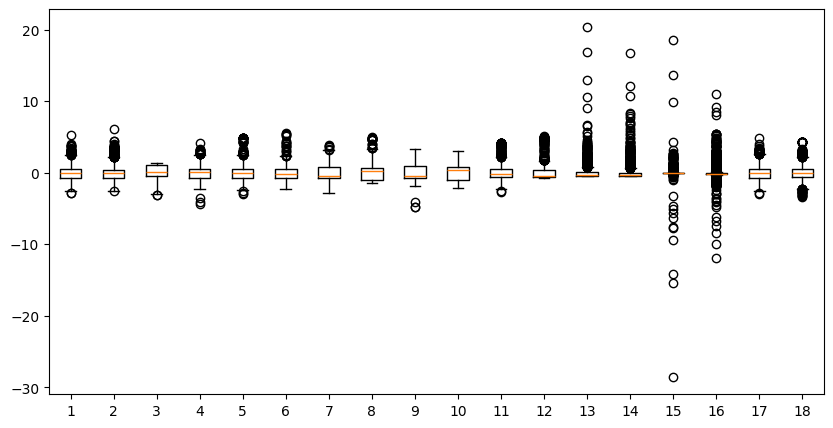

In [24]:
plt.figure(figsize=(10, 5))
plt.boxplot(feat_norm)
plt.show()

We can see that the normalisation was needed as there is a big gap in the different features scales (0.54 vs 88.51 is a big difference)

In [4]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

print('Distance between sample 0 and itself:', euclidean_distance(feat_norm[0], feat_norm[0]))
print('Distance between sample 0 and sample 1:', round(euclidean_distance(feat_norm[0], feat_norm[1]), 4))

Distance between sample 0 and itself: 0.0
Distance between sample 0 and sample 1: 6.6436


In [26]:
n_test  = len(feat_norm)
correct = 0

for i in range(n_test):
    query = feat_norm[i]
    idxs  = np.arange(n_test)
    idxs  = idxs[idxs != i]
    dists = np.array([euclidean_distance(query, feat_norm[j]) for j in idxs])
    nearest = idxs[np.argmin(dists)]
    if ocr_class[nearest] == ocr_class[i]:
        correct += 1

accuracy = correct / n_test * 100
print(f'1-NN accuracy (normalised, {n_test} test samples): {accuracy:.1f}%')

1-NN accuracy (normalised, 2392 test samples): 95.4%


## Eigenfaces

The `faces.npy` file contains a 3D matrix containing 2963 images, each with 170x200 pixels, encoded in 8-bit grayscale. 170x200 means there are 34,000 pixels per image -> very high-dimensional space. Faces are not random there are reoccuring patterns: eyes, nose, mouth, ... PCA finds the direction of maximum variance in the dataset: the eigenfaces. We can reprensent the face has a list of coefficients along the direction.

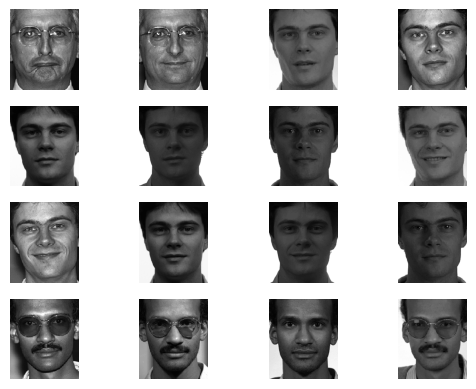

In [7]:
# Show some faces:
plt.figure()
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(faces[i], cmap=plt.cm.gray)
    plt.axis('off')
plt.show()

### Direct approach

1. Write a program that subsample the images (e.g. by 5), converts 2D images into lines, and collect all these lines into one single matrix **T**.
1. Zero-center **T** by removing the "mean image" ($T_i \leftarrow T_i - T_{mean}$)
1. Compute the variance/covariance matrix of **T**:
$$ \mathbf{S} = \mathbf{T^TT}$$
1. Compute the eigenvalues $\lambda_i$ and eigenvectors $\mathbf{v}_i$ of **S**
$$\mathbf{Sv}_i = \mathbf{T^T}\mathbf{Tv}_i = \lambda_i \mathbf{v}_i$$
1. The eigenvectors have the same size as the images, and are often referred to as "eigenfaces". Display some of them.

In [ ]:
#1 
w,v = LA.eig(np.diag((1, 2, 3)))
print(w)
print(v)

subsample = 5
T = np.array([
    faces[i][::subsample, ::subsample].flatten().astype(np.float64)
    for i in range(len(faces))
])

h_sub = faces[0][::subsample, ::subsample].shape[0]
w_sub = faces[0][::subsample, ::subsample].shape[1]
print(f'T shape: {T.shape} ({h_sub}x{w_sub} = {h_sub*w_sub} pixels per image)')

[1. 2. 3.]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
T shape: (2963, 1360) (40x34 = 1360 pixels per image)


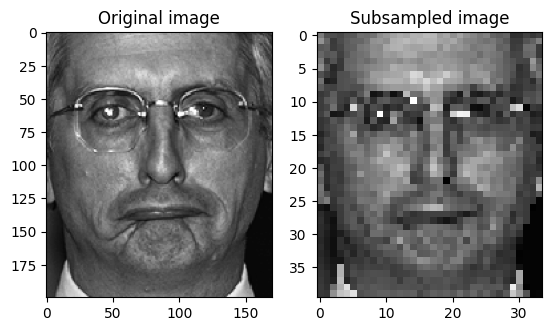

In [9]:
# Example of subsampling
im = faces[0]
plt.figure()
plt.subplot(1,2,1)
plt.imshow(im, cmap=plt.cm.gray)
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(im[::5,::5], cmap=plt.cm.gray)
plt.title("Subsampled image")
plt.show()

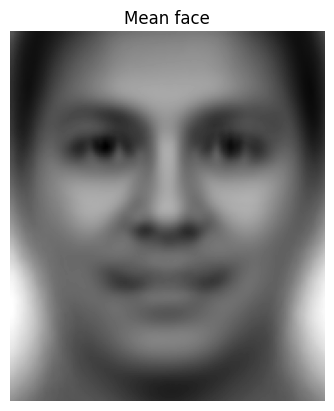

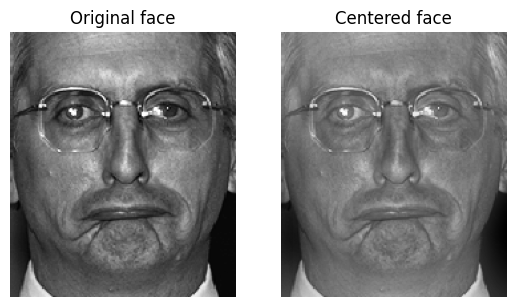

In [29]:
# Mean face

def show_mean_face(faces):
    mean_face = np.mean(faces, axis=0)
    plt.imshow(mean_face, cmap=plt.cm.gray)
    plt.title("Mean face")
    plt.axis('off')
    plt.show()
    return mean_face

mean_face = show_mean_face(faces)

face = faces[0] - mean_face
plt.figure()
plt.subplot(1,2,1)
plt.imshow(faces[0], cmap=plt.cm.gray)
plt.title("Original face")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(face, cmap=plt.cm.gray)
plt.title("Centered face")
plt.axis('off')
plt.show()


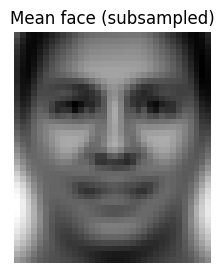

In [10]:
# 2
T_mean = T.mean(axis=0)  
T_c    = T - T_mean  

plt.figure(figsize=(3, 3))
plt.imshow(T_mean.reshape(h_sub, w_sub), cmap='gray')
plt.title('Mean face (subsampled)')
plt.axis('off')
plt.show()

In [11]:
S = T_c.T @ T_c
print('Covariance matrix S shape:', S.shape)

Covariance matrix S shape: (1360, 1360)


In [12]:
eigenvalues, eigenvectors = LA.eigh(S)

order        = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]   

print('Eigenvectors matrix shape:', eigenvectors.shape)
print('Top 5 eigenvalues:', np.round(eigenvalues[:5], 0))

Eigenvectors matrix shape: (1360, 1360)
Top 5 eigenvalues: [1.80905304e+09 1.40572718e+09 4.94243359e+08 3.88202890e+08
 3.27313474e+08]


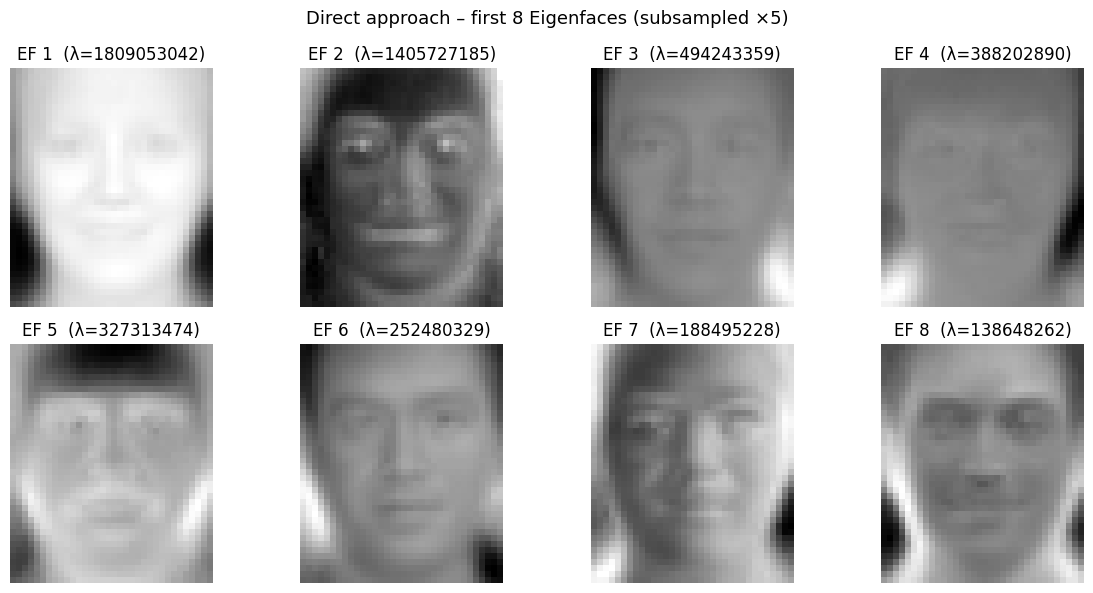

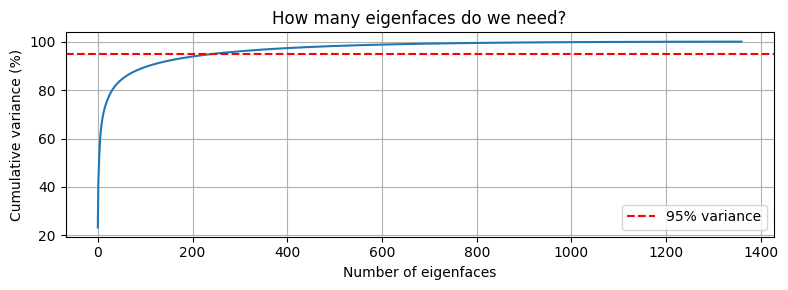

Eigenfaces needed for 95% variance: 248


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Direct approach – first 8 Eigenfaces (subsampled ×5)', fontsize=13)
for k, ax in enumerate(axes.flat):
    ef      = eigenvectors[:, k].reshape(h_sub, w_sub)
    ef_norm = (ef - ef.min()) / (ef.max() - ef.min())  # scale to [0,1] for display
    ax.imshow(ef_norm, cmap='gray')
    ax.set_title(f'EF {k+1}  (λ={eigenvalues[k]:.0f})')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Explained variance
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)
plt.figure(figsize=(8,3))
plt.plot(cumulative * 100)
plt.axhline(95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of eigenfaces'); plt.ylabel('Cumulative variance (%)')
plt.title('How many eigenfaces do we need?')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()
print(f'Eigenfaces needed for 95% variance: {np.searchsorted(cumulative, 0.95)+1}')

### Compression

1. Reconstruct images using only the first N eigenfaces (e.g. N=100).
2. Compare (visually) reconstructed images with original images

For reconstruction, we reverse the projection and add the mean back. 

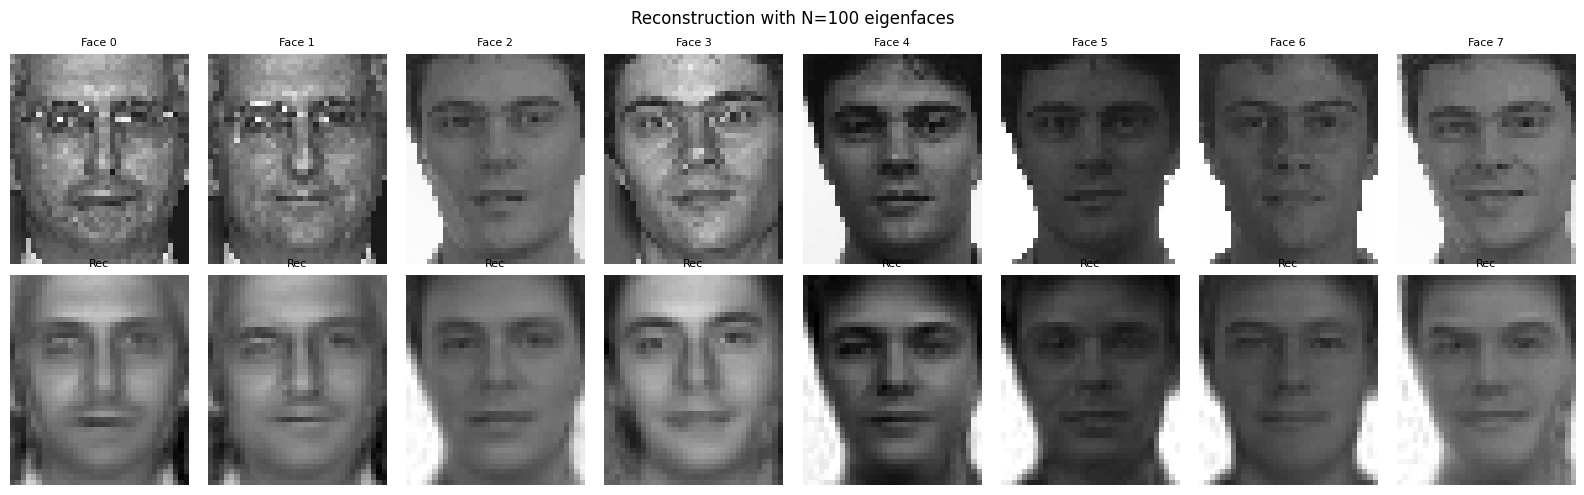

In [17]:
N_ef = 100
V_N = eigenvectors[:, :N_ef] 

def projection(face_flat_centred, V):
    return V.T @ face_flat_centred

def reconstruct(coeffs, V, mean_vec):
    return V @ coeffs + mean_vec

fig, axes = plt.subplots(2, 8, figsize=(16,5))
fig.suptitle(f'Reconstruction with N={N_ef} eigenfaces', fontsize=12)
for k in range(8):
    face_sub = faces[k][::subsample, ::subsample].flatten().astype(np.float64)
    face_c = face_sub - T_mean
    coeffs = projection(face_c, V_N)
    rec = reconstruct(coeffs, V_N, T_mean)
    rec = np.clip(rec, 0, 255).reshape(h_sub, w_sub)

    axes[0, k].imshow(faces[k][::subsample, ::subsample], cmap='gray', vmin=0, vmax=255)
    axes[0, k].set_title(f'Face {k}', fontsize=8); axes[0, k].axis('off')
    axes[1, k].imshow(rec, cmap='gray', vmin=0, vmax=255)
    axes[1, k].set_title(f'Rec', fontsize=8); axes[1, k].axis('off')
axes[0,0].set_ylabel('Original', fontsize=9)
axes[1,0].set_ylabel(f'N={N_ef}', fontsize=9)
plt.tight_layout(); plt.show()

### Face recognition

1. Using the simplified vector space (e.g. 100 first eigenfaces), compute the euclidian distance between one face and the others. (comparing the raw pixels would be too demanding)
2. For a subset of the image of the database, find the 4 closest matches.

Eigenspace coefficients matrix shape: (2963, 100)


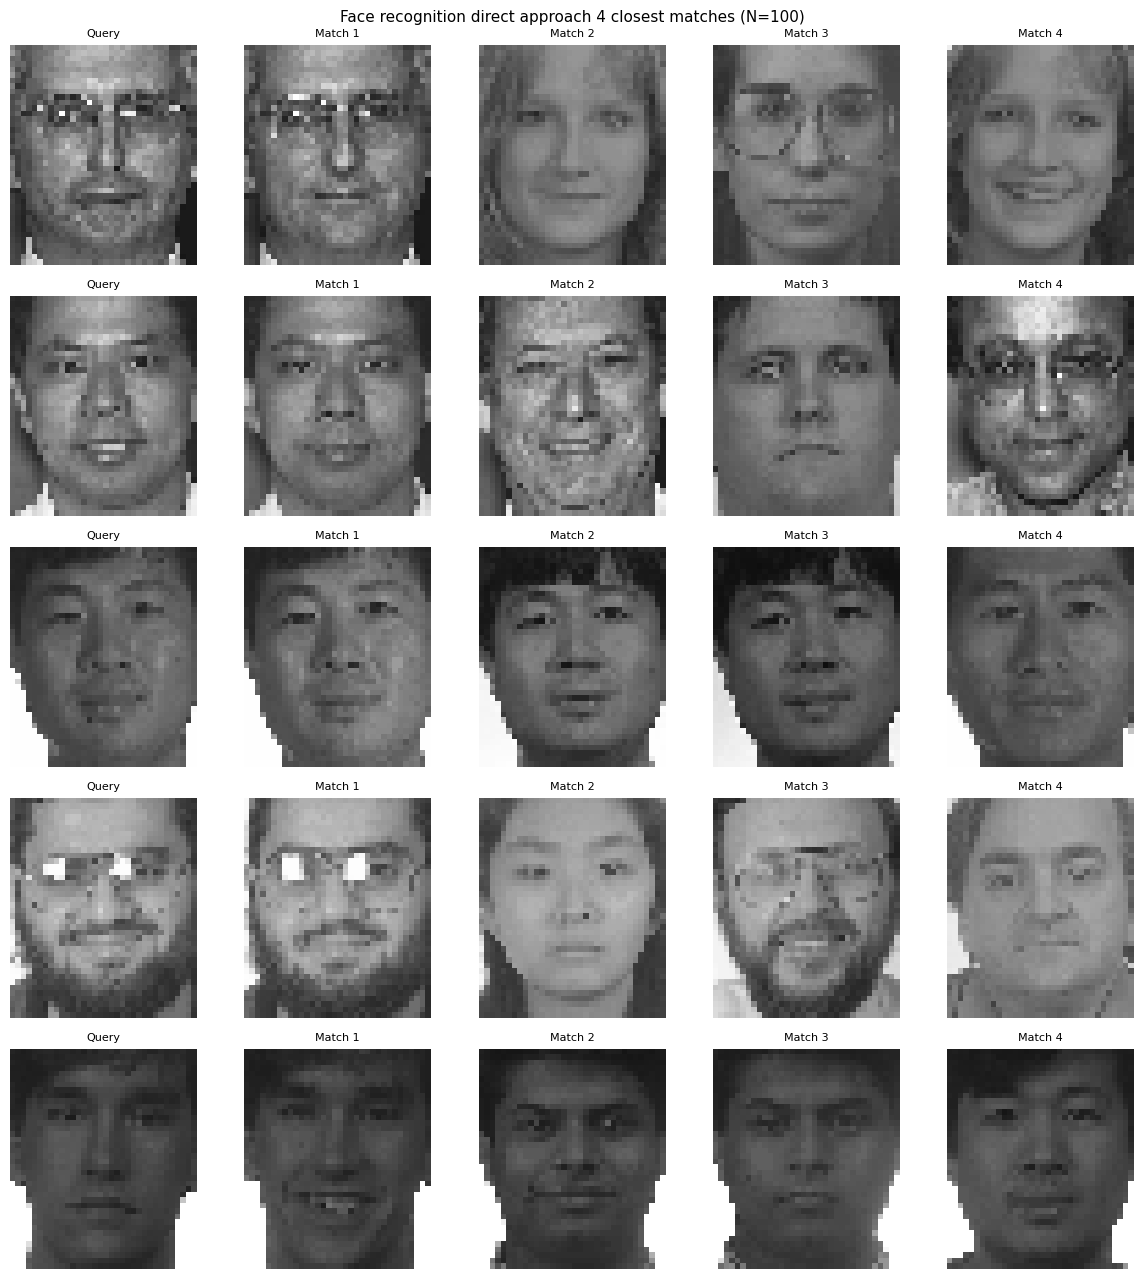

In [21]:

all_coeffs = T_c @ V_N
print('Eigenspace coefficients matrix shape:', all_coeffs.shape)

def find_top4(query_idx, coeff_matrix):
    query = coeff_matrix[query_idx]
    dist = np.sqrt(((coeff_matrix - query) ** 2).sum(axis=1))
    dist[query_idx] = np.inf
    return np.argsort(dist)[:4]

query_indices = [0, 50, 100, 300, 700]
fig, axes = plt.subplots(5, 5, figsize=(12, 13))
fig.suptitle(f'Face recognition direct approach 4 closest matches (N={N_ef})', fontsize=11)
for row, qi in enumerate(query_indices):
    top4 = find_top4(qi, all_coeffs)
    for col, idx in enumerate([qi] + list(top4)):
        axes[row, col].imshow(faces[idx][::subsample, ::subsample], cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_title('Query' if col == 0 else f'Match {col}', fontsize=8)
        axes[row, col].axis('off')
plt.tight_layout(); plt.show()


### Indirect approach

Instead of using the eigenvalues/eigenvectors of $\mathbf{S} = \mathbf{T^TT}$, compute the the eigenvalues/eigenvectors of $\mathbf{Q} = \mathbf{TT^T}$.

Let $\mathbf{u_i}$ be the eigenvectors of $\mathbf{Q}$. We have:
$$\mathbf{TT^T}\mathbf{u}_i = \lambda_i \mathbf{u}_i$$

By multiplying to the left with $\mathbf{T^T}$, we have:
$$\mathbf{T^T}\mathbf{TT^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$
$$\mathbf{S}\mathbf{T^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$

Which means that if $\mathbf{u}_i$ is eigenvector of $\mathbf{Q}$, then $\mathbf{T^T}\mathbf{u}_i$ is eigenvector of $\mathbf{S}$.

The indirect approach thus becomes:
1. Compute the eigenvectors $\mathbf{u}_i$ of $\mathbf{Q} = \mathbf{TT^T}$.
1. Compute the eigenfaces with $\mathbf{v}_i = \mathbf{T^T}\mathbf{u}_i$ 
1. Reconstruct the images using only the first N eigenfaces (e.g. N=100)
1. Compare (visually) reconstructed images with original images
1. Use the indirect approach with more resolution (without subsampling the images)

Use this new feature space to perform the same face recognition method.

T_full shape: (2963, 34000)
Q shape: (2963, 2963)
Eigenfaces matrix shape (indirect): (34000, 100)


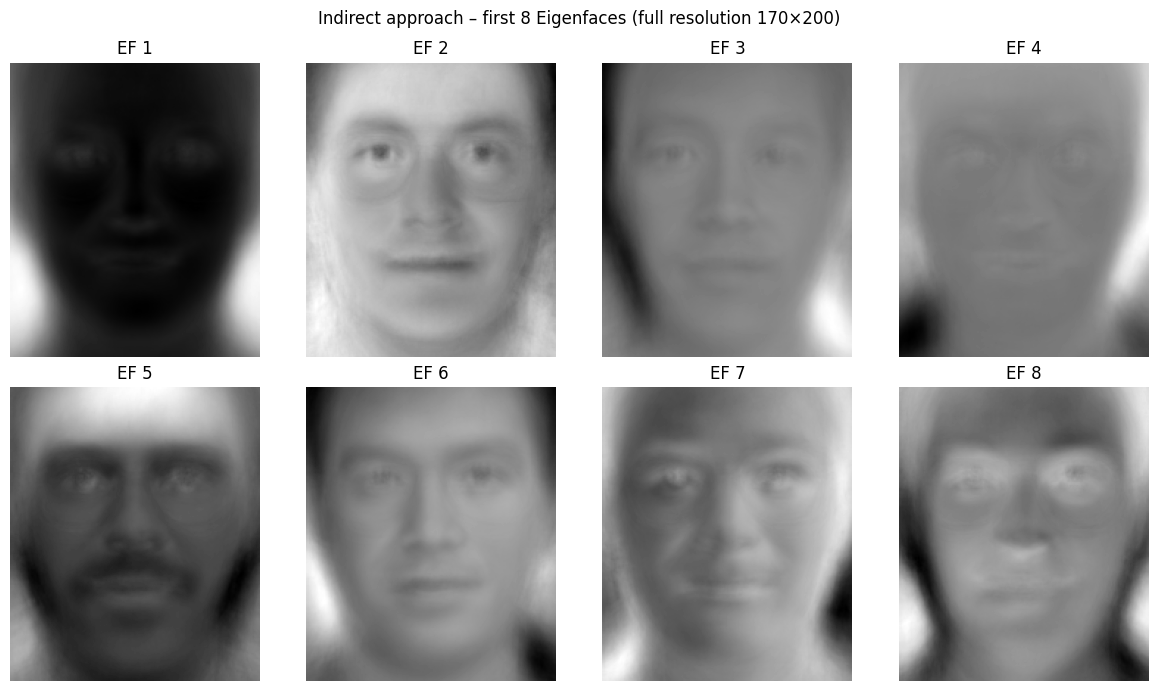

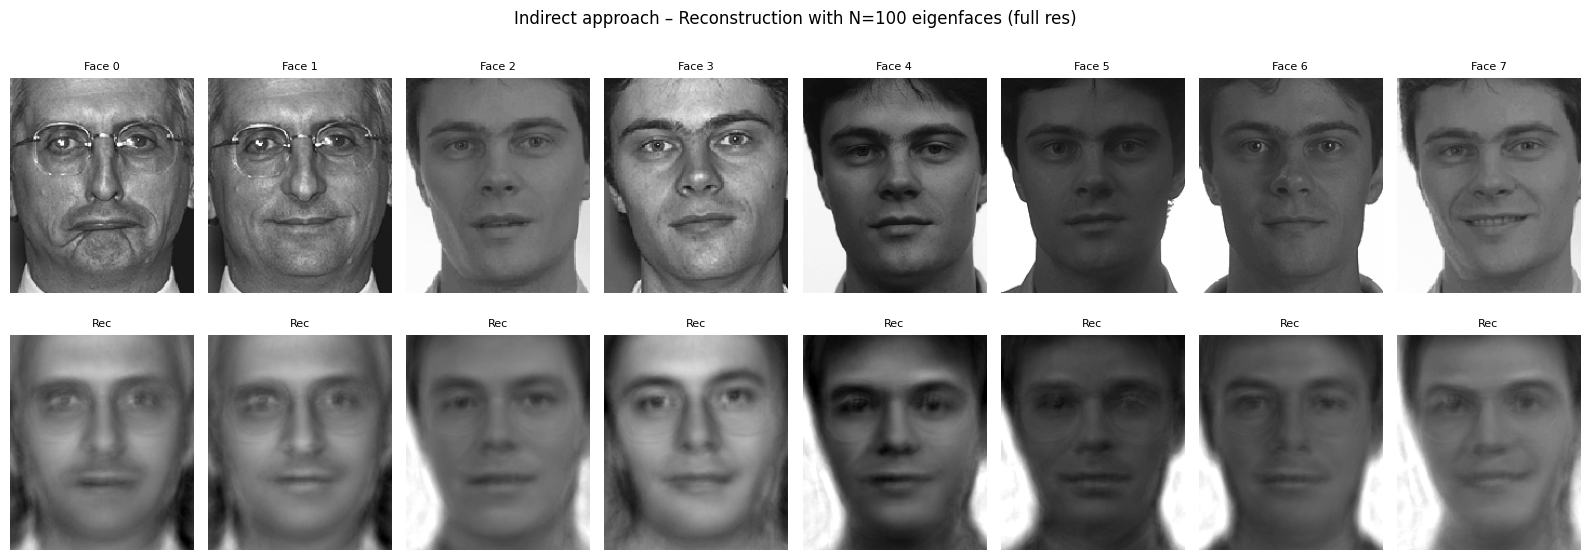

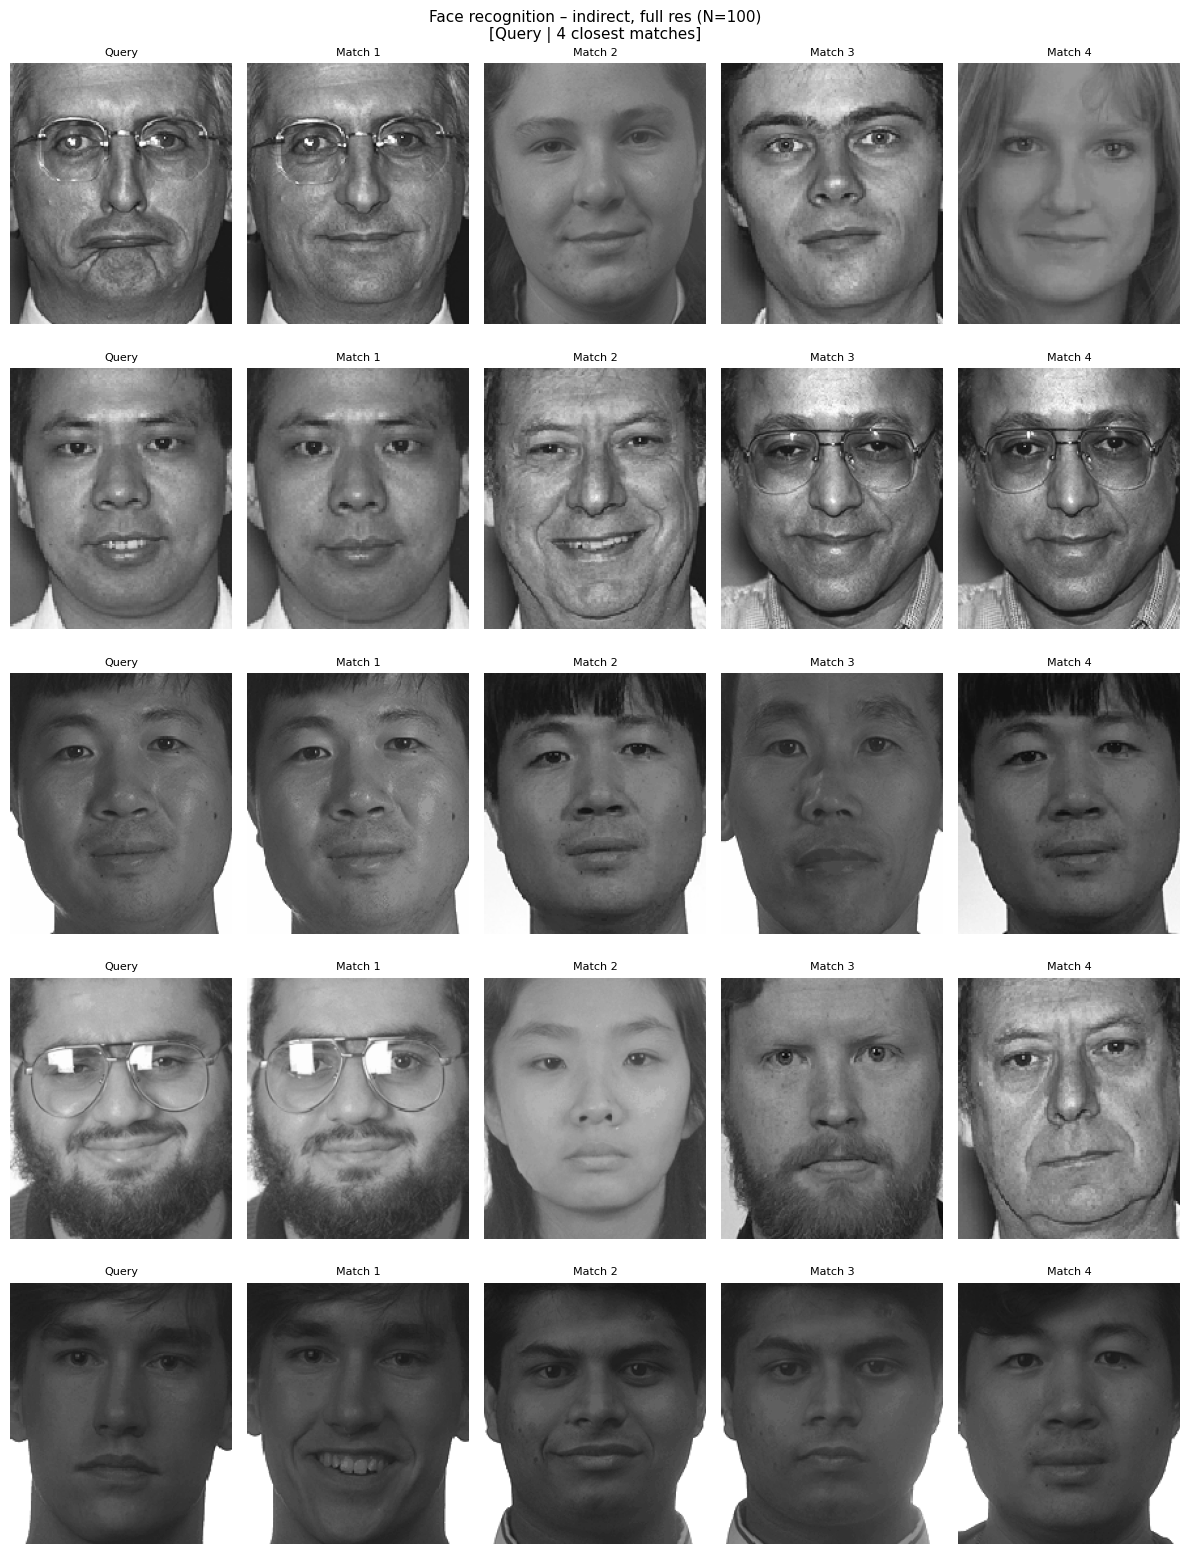


Key insight: Full-resolution eigenfaces capture finer details
→ better face recognition than the subsampled direct approach!


In [22]:

h, w = faces[0].shape 
T_full = faces.reshape(len(faces), -1).astype(np.float64)
T_mean_f = T_full.mean(axis=0)
T_cf = T_full - T_mean_f
print('T_full shape:', T_full.shape)

Q = T_cf @ T_cf.T
print('Q shape:', Q.shape) 
eigvals_q, U = LA.eigh(Q)
order_q      = np.argsort(eigvals_q)[::-1]
U            = U[:, order_q]

N_keep = 100
U_N = U[:, :N_keep]
V_indirect = T_cf.T @U_N
V_indirect /= np.linalg.norm(V_indirect, axis=0)
print('Eigenfaces matrix shape (indirect):', V_indirect.shape)

fig, axes = plt.subplots(2, 4, figsize=(12, 7))
fig.suptitle('Indirect approach – first 8 Eigenfaces (full resolution 170×200)', fontsize=12)
for k, ax in enumerate(axes.flat):
    ef      = V_indirect[:, k].reshape(h, w)
    ef_norm = (ef - ef.min()) / (ef.max() - ef.min())
    ax.imshow(ef_norm, cmap='gray')
    ax.set_title(f'EF {k+1}')
    ax.axis('off')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 8, figsize=(16, 6))
fig.suptitle(f'Indirect approach – Reconstruction with N={N_keep} eigenfaces (full res)', fontsize=12)
for k in range(8):
    face_c  = T_cf[k]
    coeffs  = V_indirect.T @ face_c
    rec     = np.clip(V_indirect @ coeffs + T_mean_f, 0, 255).reshape(h, w)

    axes[0, k].imshow(faces[k], cmap='gray', vmin=0, vmax=255)
    axes[0, k].set_title(f'Face {k}', fontsize=8); axes[0, k].axis('off')
    axes[1, k].imshow(rec, cmap='gray', vmin=0, vmax=255)
    axes[1, k].set_title('Rec', fontsize=8); axes[1, k].axis('off')
axes[0,0].set_ylabel('Original', fontsize=9)
axes[1,0].set_ylabel(f'N={N_keep}', fontsize=9)
plt.tight_layout(); plt.show()

all_coeffs_ind = T_cf @ V_indirect   # (2963, 100)

fig, axes = plt.subplots(5, 5, figsize=(12, 16))
fig.suptitle(f'Face recognition – indirect, full res (N={N_keep})\n[Query | 4 closest matches]', fontsize=11)
for row, qi in enumerate(query_indices):
    top4 = find_top4(qi, all_coeffs_ind)
    for col, idx in enumerate([qi] + list(top4)):
        axes[row, col].imshow(faces[idx], cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_title('Query' if col == 0 else f'Match {col}', fontsize=8)
        axes[row, col].axis('off')
plt.tight_layout(); plt.show()

print('\nKey insight: Full-resolution eigenfaces capture finer details')
print('→ better face recognition than the subsampled direct approach!')